'housing.csv' already exists. Skipping file upload prompt and loading it.
Dataset Loaded Successfully
Shape: (20640, 10)

First 5 Rows


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Columns
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Data Types
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN



Missing Values
total_bedrooms    207
dtype: int64

Duplicate Rows
0

Missing Values After Cleaning
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


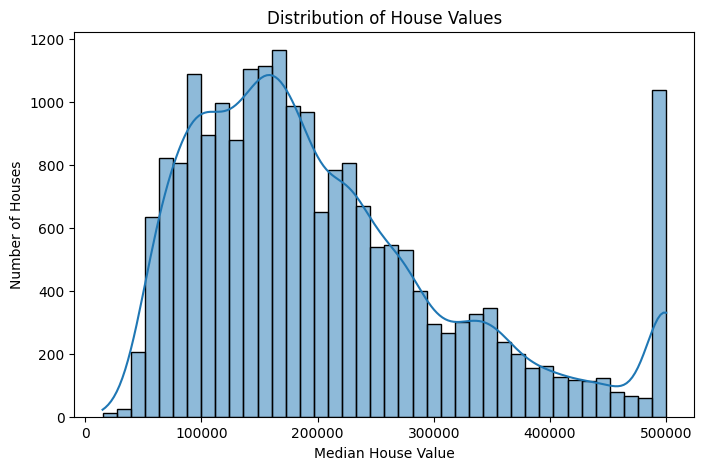

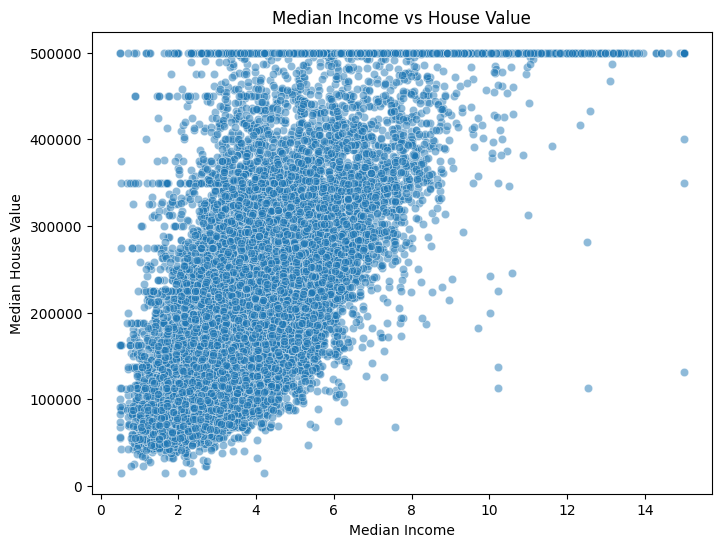

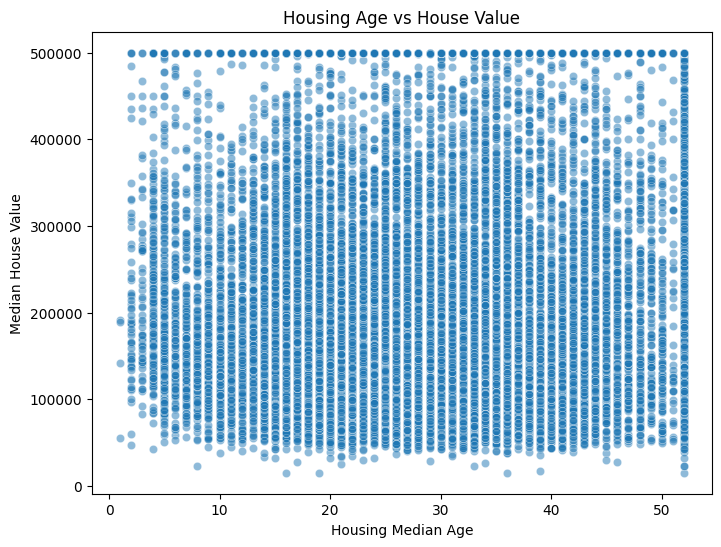

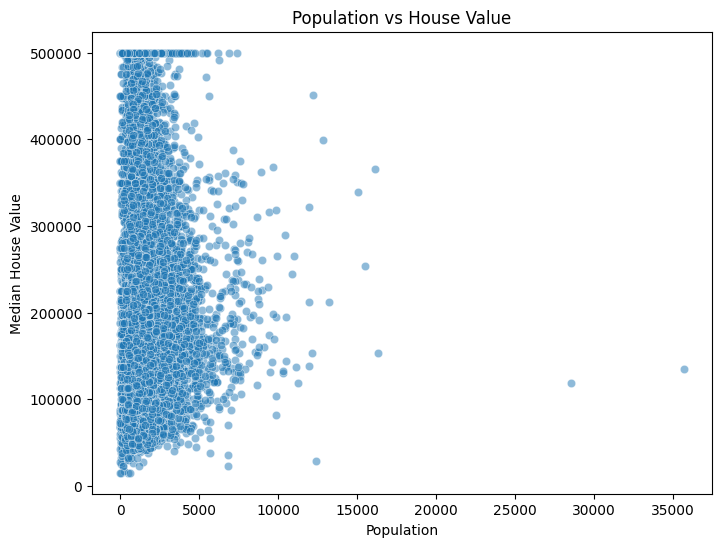

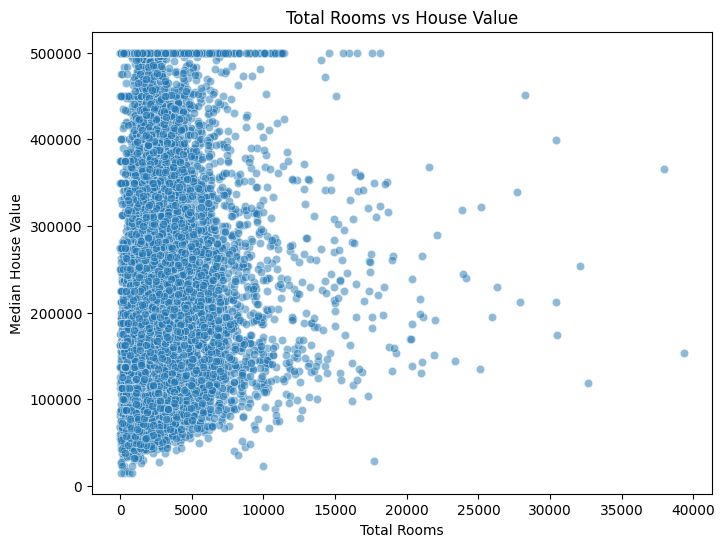


Correlation With House Value
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


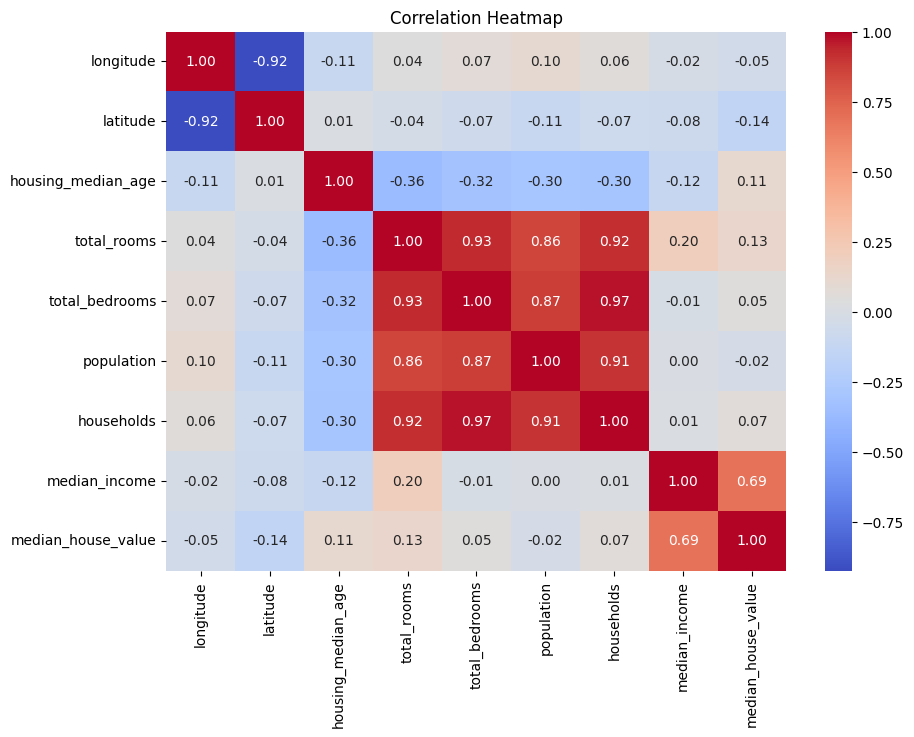


Linear Regression
MAE: 50670.73824097423
RMSE: 70060.52184473512
R2 Score: 0.6254240620553613

Random Forest
MAE: 31524.63348029716
RMSE: 48834.19476653472
R2 Score: 0.8180126496311719

Model Comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,50670.738241,70060.521845,0.625424
1,Random Forest,31524.633480,48834.194767,0.818013


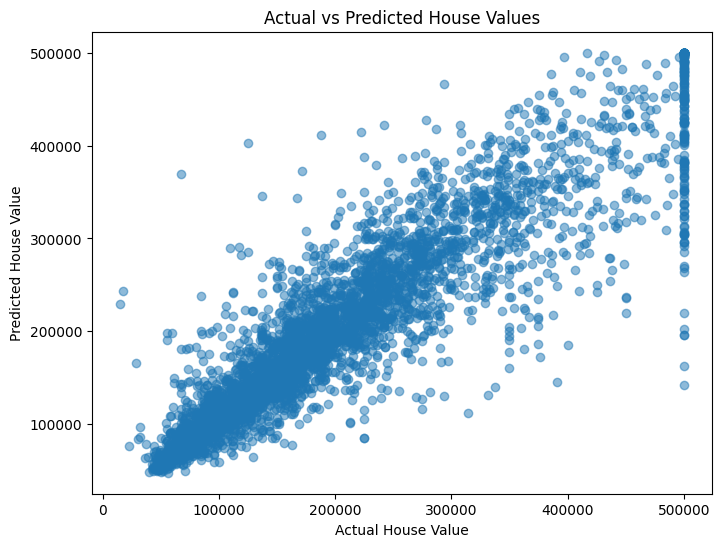


Top 15 Important Features


,Feature,Importance
7,numeric__median_income,0.490720
9,categorical__ocean_proximity_INLAND,0.141216
0,numeric__longitude,0.105627
1,numeric__latitude,0.101536
2,numeric__housing_median_age,0.052170
5,numeric__population,0.032560
3,numeric__total_rooms,0.023487
4,numeric__total_bedrooms,0.023443
6,numeric__households,0.018290
12,categorical__ocean_proximity_NEAR OCEAN,0.006493


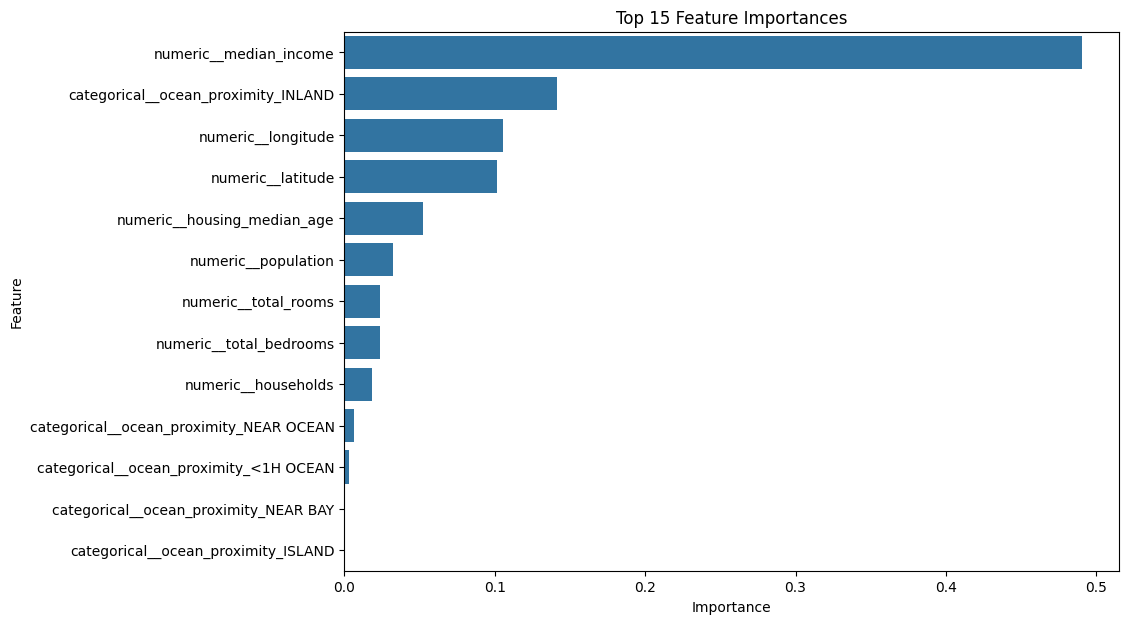


Best Model: Random Forest
Best R2 Score: 0.8180126496311719

House_Price_Predictions.csv Saved Successfully

Task 1 - House Price Prediction Completed Successfully.

The dataset was loaded and cleaned by handling
missing values and duplicate records.

Exploratory Data Analysis was performed to understand
the relationships between different housing features
and house values.

Linear Regression and Random Forest Regression were
used for house price prediction.

The models were evaluated using MAE, RMSE and R2 Score.

The best-performing model was selected based on R2 Score.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os # Added import for os module
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- MODIFIED FILE UPLOAD LOGIC START ---
desired_file_name = "housing.csv"
actual_file_to_read = desired_file_name # Initialize with desired name

if not os.path.exists(desired_file_name):
    print(f"'{desired_file_name}' not found. Please upload the file.")
    uploaded = files.upload()
    if uploaded:
        # Get the name of the first uploaded file
        actual_file_to_read = list(uploaded.keys())[0]
        print(f"Successfully uploaded: '{actual_file_to_read}'.")
    else:
        print("No file was uploaded. Please upload 'housing.csv' to proceed.")
        raise FileNotFoundError(f"Required file '{desired_file_name}' not found and not uploaded.")
else:
    print(f"'{desired_file_name}' already exists. Skipping file upload prompt and loading it.")

df = pd.read_csv(actual_file_to_read) # Use the variable to read the file
# --- MODIFIED FILE UPLOAD LOGIC END ---

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

print("\nFirst 5 Rows")
display(df.head())

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe(include="all"))

print("\nMissing Values")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

print("\nDuplicate Rows")
print(df.duplicated().sum())

df = df.copy()

df.drop_duplicates(inplace=True)

if "total_bedrooms" in df.columns:
    df["total_bedrooms"] = df["total_bedrooms"].fillna(
        df["total_bedrooms"].median()
    )

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="median_house_value",
    bins=40,
    kde=True
)
plt.title("Distribution of House Values")
plt.xlabel("Median House Value")
plt.ylabel("Number of Houses")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="median_income",
    y="median_house_value",
    alpha=0.5
)
plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="housing_median_age",
    y="median_house_value",
    alpha=0.5
)
plt.title("Housing Age vs House Value")
plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="population",
    y="median_house_value",
    alpha=0.5
)
plt.title("Population vs House Value")
plt.xlabel("Population")
plt.ylabel("Median House Value")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="total_rooms",
    y="median_house_value",
    alpha=0.5
)
plt.title("Total Rooms vs House Value")
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.show()

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print("\nCorrelation With House Value")
print(
    correlation["median_house_value"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("\nLinear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("\nRandom Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

print("\nModel Comparison")
display(results)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

rf_model = random_forest.named_steps["model"]

feature_names = random_forest.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Important Features")
display(feature_importance.head(15))

plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

if rf_r2 > linear_r2:
    best_model = "Random Forest"
    best_r2 = rf_r2
else:
    best_model = "Linear Regression"
    best_r2 = linear_r2

print("\nBest Model:", best_model)
print("Best R2 Score:", best_r2)

prediction_output = pd.DataFrame({
    "Actual_House_Value": y_test.values,
    "Predicted_House_Value": rf_predictions
})

prediction_output.to_csv(
    "House_Price_Predictions.csv",
    index=False
)

print("\nHouse_Price_Predictions.csv Saved Successfully")

print("""
Task 1 - House Price Prediction Completed Successfully.

The dataset was loaded and cleaned by handling
missing values and duplicate records.

Exploratory Data Analysis was performed to understand
the relationships between different housing features
and house values.

Linear Regression and Random Forest Regression were
used for house price prediction.

The models were evaluated using MAE, RMSE and R2 Score.

The best-performing model was selected based on R2 Score.
""")